![JohnSnowLabs](https://sparknlp.org/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp/blob/master/examples/python/annotation/text/english/retrieval-augmented-generation/BiEncoderMultimodalEmbeddings_OpsMM_Pinecone_RAG.ipynb)

# End-to-End Multimodal RAG with BiEncoderMultimodalEmbeddings, OpsMM, and Pinecone

This notebook turns the retrieval pattern into a complete RAG workflow:

1. Build a synthetic OpsMM document from HTML plus a real damage photo.
2. Use `ReaderAssembler` and `LayoutAlignerForVision` to create aligned text/image retrieval units.
3. Embed both sides with `BiEncoderMultimodalEmbeddings` using OpsMM.
4. Upsert text and image vectors with `VectorDBConnector` into Pinecone.
5. Encode a user query, retrieve top-k evidence with Pinecone, and synthesize a grounded answer.

The example follows the retrieval-first mental model: OpsMM retrieves grounded evidence; a downstream NLP/generation step turns that evidence into the answer.

## Current component boundaries

Two implementation details are explicit in this notebook:

- `VectorDBConnector` is the Spark NLP annotator for upserting vectors to Pinecone. The current connector does not expose a query/retrieval transformer, so the query call uses the Pinecone Python client.
- `BiEncoderMultimodalEmbeddings` currently has a `DOCUMENT, IMAGE` input contract. For a text query, the notebook supplies a neutral placeholder image and uses the doc-side query embedding column.

## 0. Setup

You need a [Pinecone](https://www.pinecone.io/) API key with access to a serverless index.

In [1]:
!pip install -q pyspark spark-nlp pinecone

In [2]:
import base64
import os
import pathlib
import textwrap
import time
import urllib.request

import pandas as pd
import sparknlp
from IPython.display import HTML, display
from pinecone import Pinecone, ServerlessSpec
from pyspark.ml import Pipeline
from pyspark.sql import Window
from pyspark.sql import functions as F

from sparknlp.base import DocumentAssembler, ImageAssembler
from sparknlp.annotator import AutoGGUFModel, BiEncoderMultimodalEmbeddings, VectorDBConnector
from sparknlp.reader import LayoutAlignerForVision, ReaderAssembler

PINECONE_API_KEY = os.environ.get("PINECONE_API_KEY", "")

In [3]:
import sparknlp

spark = sparknlp.start(params={
    "spark.jsl.settings.vectordb.api.key": PINECONE_API_KEY,
})

26/05/19 15:16:42 WARN Utils: Your hostname, danilo-ubuntu resolves to a loopback address: 127.0.1.1; using 192.168.100.76 instead (on interface enp131s0)
26/05/19 15:16:42 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
26/05/19 15:16:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


In [5]:
print("Spark NLP version:", sparknlp.version())
print("Apache Spark version:", spark.version)

Spark NLP version: 6.4.0
Apache Spark version: 3.5.6


## 1. Configuration

The Pinecone index dimension is inferred after the first OpsMM embedding pass. If the index already exists, it must have the same dimension and use a similarity metric appropriate for normalized embedding search, such as cosine.

In [ ]:
BASE_DIR = pathlib.Path("tmp/opsmm_multimodal_rag").resolve()
BASE_DIR.mkdir(parents=True, exist_ok=True)

SAMPLE_HTML_PATH = BASE_DIR / "opsmm_shipping_claim.html"
DAMAGE_IMAGE_PATH = BASE_DIR / "damaged_fragile_parcel.jpg"
QUERY_PLACEHOLDER_IMAGE_PATH = BASE_DIR / "query_placeholder.png"

# Real photo used as visual evidence in the synthetic HTML document.
DAMAGE_IMAGE_URL = (
    "https://upload.wikimedia.org/wikipedia/commons/thumb/b/b7/"
    "Damaged_fragile_parcel_delivered_to_doorstep.jpg/960px-"
    "Damaged_fragile_parcel_delivered_to_doorstep.jpg"
)
DAMAGE_IMAGE_ATTRIBUTION = "Meanwell Packaging, CC BY 2.0, via Wikimedia Commons"

OPSMM_MODEL_NAME = "ops_mm_embedding_v1_2b"
OPSMM_INDEX_NAME = os.environ.get("PINECONE_INDEX_NAME", "opsmm-multimodal-rag-demo")
OPSMM_NAMESPACE = os.environ.get("PINECONE_NAMESPACE", "opsmm-shipping-claims")
PINECONE_CLOUD = os.environ.get("PINECONE_CLOUD", "aws")
PINECONE_REGION = os.environ.get("PINECONE_REGION", "us-east-1")

print("Working directory:", BASE_DIR)
print("Pinecone index:", OPSMM_INDEX_NAME)
print("Pinecone namespace:", OPSMM_NAMESPACE)

## 2. Create one synthetic multimodal document

The data is intentionally small to showcase one OpsMM shipping-claims HTML file with one real photo and enough nearby text for `LayoutAlignerForVision` to pair the image with the right claim context.


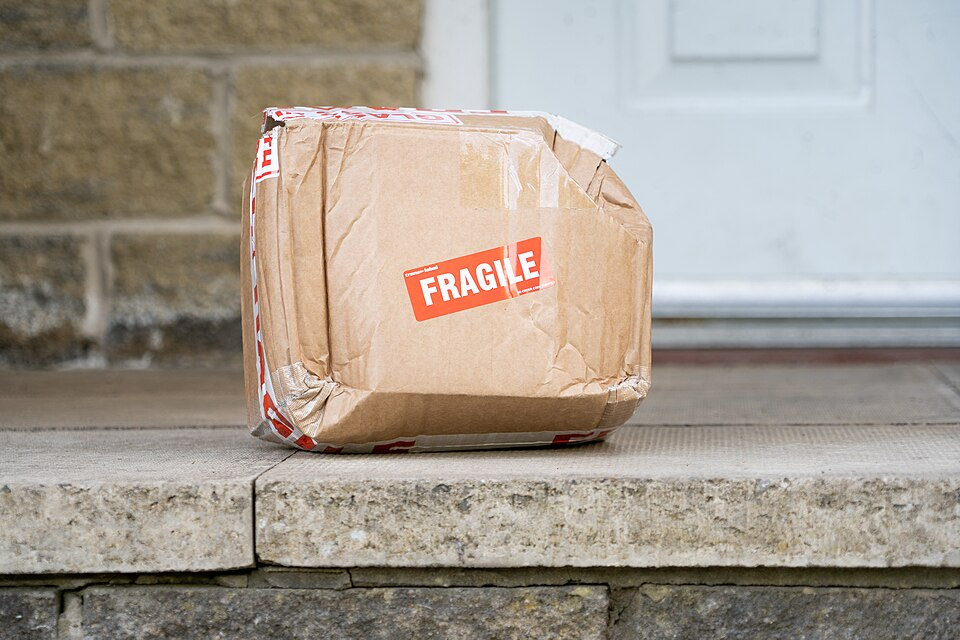

In [7]:
def download_if_missing(url, path):
    if path.exists() and path.stat().st_size > 0:
        return

    request = urllib.request.Request(
        url,
        headers={
            "User-Agent": "Mozilla/5.0 SparkNLP-OpsMM-RAG-Notebook/1.0",
            "Accept": "image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8",
        },
    )

    try:
        with urllib.request.urlopen(request, timeout=30) as response:
            path.write_bytes(response.read())
    except Exception as exc:
        raise RuntimeError(
            f"Could not download the sample image from {url}. "
            "If your notebook environment blocks external image downloads, "
            f"manually place a damage-package JPEG at {path} and rerun this cell."
        ) from exc


def write_query_placeholder(path):
    # A tiny transparent PNG. It is only needed because the current OpsMM annotator
    # contract requires DOCUMENT and IMAGE inputs for query embedding.
    transparent_png = (
        "iVBORw0KGgoAAAANSUhEUgAAAAEAAAABCAQAAAC1HAwCAAAAC0l"
        "EQVR42mP8/x8AAwMCAO+/p9sAAAAASUVORK5CYII="
    )
    path.write_bytes(base64.b64decode(transparent_png))


download_if_missing(DAMAGE_IMAGE_URL, DAMAGE_IMAGE_PATH)
write_query_placeholder(QUERY_PLACEHOLDER_IMAGE_PATH)

image_b64 = base64.b64encode(DAMAGE_IMAGE_PATH.read_bytes()).decode("ascii")

html_doc = f"""<!doctype html>
<html>
<head>
  <meta charset="utf-8">
  <title>OpsMM Shipping Claim OP-103</title>
</head>
<body>
  <article>
    <h1>Shipping Claim OP-103: Packaging Damage During Transit</h1>
    <p>
      Customer reported that a fragile electronics parcel arrived with a crushed left corner,
      torn outer carton, dented top edge, and visible compression marks after shipping.
      The carrier scan history indicates the package was compressed during warehouse handling.
    </p>
    <figure>
      <img src="data:image/jpeg;base64,{image_b64}"
           alt="Damaged fragile parcel with crushed cardboard corners and torn outer carton"
           width="640">
      <figcaption>
        Evidence photo for claim OP-103: crushed fragile parcel and torn outer carton.
        Source: {DAMAGE_IMAGE_ATTRIBUTION}.
      </figcaption>
    </figure>
    <h2>Adjuster Notes</h2>
    <p>
      The damage pattern is consistent with packaging damage in shipping: corner impact,
      compression during transit, and deformation of the outside carton. Prior similar cases
      should include damage photos, inspection notes, and resolution details.
    </p>
    <h2>Resolution Guidance</h2>
    <p>
      Triage as packaging damage. Request prior documents related to damaged parcels,
      crushed cartons, fragile-item handling, and warehouse compression events.
    </p>
  </article>
</body>
</html>
"""

SAMPLE_HTML_PATH.write_text(html_doc, encoding="utf-8")

display(HTML(SAMPLE_HTML_PATH.read_text(encoding="utf-8")))

## 3. Read and align text with the image

`ReaderAssembler` extracts text and image annotations from the HTML. `LayoutAlignerForVision` then creates aligned outputs based on `outputCol="vision_pair"`:

- `vision_pair_doc`
- `vision_pair_image`
- `vision_pair_prompt`

The retrieval pipeline uses the document and image columns as separate inputs to OpsMM.

In [8]:
empty_df = spark.createDataFrame([[""]]).toDF("text")

In [9]:
reader = (
    ReaderAssembler()
    .setContentPath(SAMPLE_HTML_PATH.as_uri())
    .setContentType("text/html")
    .setOutputCol("reader")
    .setOutputAsDocument(False)
    .setExplodeDocs(False)
)

vision_aligner = (
    LayoutAlignerForVision()
    .setInputCols(["reader_text", "reader_image"])
    .setOutputCol("vision_pair")
    .setExplodeDocs(True)
    .setMergeImagesPerChunk(False)
    .setAddNeighborText(True)
    .setNeighborTextCharsWindow(512)
)

opsmm_embeddings = (
    BiEncoderMultimodalEmbeddings.pretrained()
    .setInputCols(["vision_pair_doc", "vision_pair_image"])
    .setOutputCol("mm")
    .setBatchSize(1)
)

The embeddings flow is:
```
vision_pair_doc/image
        +
mm_doc_embeddings/mm_image_embeddings
        ↓
VectorDBConnector
        ↓
Pinecone vector upsert
```

In [12]:
embedding_pipeline = Pipeline(stages=[reader, vision_aligner, opsmm_embeddings])
embedded = embedding_pipeline.fit(empty_df).transform(empty_df).cache()

embedded.selectExpr(
    "fileName",
    "size(vision_pair_doc) as aligned_text_units",
    "size(vision_pair_image) as aligned_image_units",
    "size(mm_doc_embeddings) as doc_embedding_units",
    "size(mm_image_embeddings) as image_embedding_units"
).show(truncate=False)

Using CPUs


[Stage 8:>                                                          (0 + 1) / 1]

Using CPUs
+-------------------------+------------------+-------------------+-------------------+---------------------+
|fileName                 |aligned_text_units|aligned_image_units|doc_embedding_units|image_embedding_units|
+-------------------------+------------------+-------------------+-------------------+---------------------+
|opsmm_shipping_claim.html|1                 |1                  |1                  |1                    |
+-------------------------+------------------+-------------------+-------------------+---------------------+



In [13]:
embedded.select(
    "fileName",
    F.col("vision_pair_doc").getItem(0).getField("result").alias("aligned_text"),
    F.col("vision_pair_image").getItem(0).getField("origin").alias("image_origin"),
).show(truncate=120)

+-------------------------+------------------------------------------------------+-------------------------+
|                 fileName|                                          aligned_text|             image_origin|
+-------------------------+------------------------------------------------------+-------------------------+
|opsmm_shipping_claim.html|Shipping Claim OP-103: Packaging Damage During Transit|opsmm_shipping_claim.html|
+-------------------------+------------------------------------------------------+-------------------------+



## 4. Prepare stable vector records

OpsMM emits separate embedding columns for the same aligned pair. We keep both modalities in one Pinecone namespace and use metadata to preserve the evidence payload.

In [14]:
def first_embedding_from_row(row, column):
    annotation = row[column][0]
    try:
        return list(annotation["embeddings"])
    except TypeError:
        return list(annotation.embeddings)


first_vector_row = (
    embedded
    .where(F.size("mm_doc_embeddings") > 0)
    .select("mm_doc_embeddings")
    .first()
)

if first_vector_row is None:
    raise ValueError("No OpsMM embeddings were produced. Check that the HTML image was extracted.")

OPSMM_DIMENSION = len(first_embedding_from_row(first_vector_row, "mm_doc_embeddings"))
print("OpsMM embedding dimension:", OPSMM_DIMENSION)

OpsMM embedding dimension: 1536


The code below turns each “document + image” pair from embedded into two vector records: one text record and one image record, sharing the same metadata.

In [15]:
pair_window = Window.orderBy("fileName")

# Filter rows that contain both text and image annotations to build the shared base record
records = (
    embedded
    .where((F.size("vision_pair_doc") > 0) & (F.size("vision_pair_image") > 0))
    .withColumn("pair_ordinal", F.row_number().over(pair_window))
    .withColumn("case_id", F.lit("case_103"))
    .withColumn("source_file", F.coalesce(F.col("fileName"), F.lit(SAMPLE_HTML_PATH.name)))
    .withColumn("query_hint", F.lit("packaging damage in shipping"))
    .withColumn("payload_text", F.col("vision_pair_doc").getItem(0).getField("result"))
    .withColumn("image_origin", F.col("vision_pair_image").getItem(0).getField("origin"))
    .withColumn(
        "image_caption",
        F.lit("Photo evidence showing a crushed fragile parcel, torn cardboard, and packaging deformation.")
    )
    .cache()
)

text_records = (
    records
    .withColumn("vector_id", F.concat(F.lit("case_103_text_"), F.col("pair_ordinal")))
    .withColumn("record_modality", F.lit("text"))
)

image_records = (
    records
    .withColumn("vector_id", F.concat(F.lit("case_103_image_"), F.col("pair_ordinal")))
    .withColumn("record_modality", F.lit("image"))
)

METADATA_COLUMNS = [
    "case_id",
    "source_file",
    "record_modality",
    "query_hint",
    "payload_text",
    "image_caption",
    "image_origin",
]

text_records.select("vector_id", "case_id", "record_modality", "payload_text").show(truncate=100)
image_records.select("vector_id", "case_id", "record_modality", "image_caption").show(truncate=100)

26/05/19 15:17:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/19 15:17:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/19 15:17:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/19 15:17:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/19 15:17:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/19 15:17:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/19 1

+---------------+--------+---------------+------------------------------------------------------+
|      vector_id| case_id|record_modality|                                          payload_text|
+---------------+--------+---------------+------------------------------------------------------+
|case_103_text_1|case_103|           text|Shipping Claim OP-103: Packaging Damage During Transit|
+---------------+--------+---------------+------------------------------------------------------+

+----------------+--------+---------------+-------------------------------------------------------------------------------------------+
|       vector_id| case_id|record_modality|                                                                              image_caption|
+----------------+--------+---------------+-------------------------------------------------------------------------------------------+
|case_103_image_1|case_103|          image|Photo evidence showing a crushed fragile parcel, torn card

## 5. Create or connect to the Pinecone index

The `VectorDBConnector` upserts to an existing Pinecone index. The Pinecone client is used here only for index administration and retrieval.

In [16]:
if not PINECONE_API_KEY:
    raise ValueError(
        "Set PINECONE_API_KEY in the environment before running Pinecone cells. "
        "For example: os.environ['PINECONE_API_KEY'] = '...'"
    )

pc = Pinecone(api_key=PINECONE_API_KEY)


def pinecone_index_names(client):
    indexes = client.list_indexes()
    if hasattr(indexes, "names"):
        return indexes.names()
    return [item["name"] if isinstance(item, dict) else item.name for item in indexes]


def is_index_ready(description):
    status = getattr(description, "status", {})
    if isinstance(status, dict):
        return status.get("ready", False)
    return getattr(status, "ready", False)


def index_host(description):
    if isinstance(description, dict):
        return description["host"]
    return description.host


if OPSMM_INDEX_NAME not in pinecone_index_names(pc):
    pc.create_index(
        name=OPSMM_INDEX_NAME,
        dimension=OPSMM_DIMENSION,
        metric="cosine",
        spec=ServerlessSpec(cloud=PINECONE_CLOUD, region=PINECONE_REGION),
    )

index_description = pc.describe_index(OPSMM_INDEX_NAME)
while not is_index_ready(index_description):
    time.sleep(5)
    index_description = pc.describe_index(OPSMM_INDEX_NAME)

index = pc.Index(host=index_host(index_description))
index.describe_index_stats()

DescribeIndexStatsResponse(dimension=1536, total_vector_count=2, metric='cosine', namespaces=1)

## 6. Upsert text and image evidence with VectorDBConnector

Both modalities are written to the same Pinecone namespace. The `modalityMode` parameter controls whether the connector validates `DOCUMENT + SENTENCE_EMBEDDINGS` or `IMAGE + SENTENCE_EMBEDDINGS` inputs.

In [17]:
# Optional reset for repeated demos. Uncomment if you want a clean namespace.
# index.delete(delete_all=True, namespace=OPSMM_NAMESPACE)

text_vector_db = (
    VectorDBConnector()
    .setInputCols(["vision_pair_doc", "mm_doc_embeddings"])
    .setOutputCol("opsmm_text_index_result")
    .setProvider("pinecone")
    .setIndexName(OPSMM_INDEX_NAME)
    .setNamespace(OPSMM_NAMESPACE)
    .setIdColumn("vector_id")
    .setMetadataColumns(METADATA_COLUMNS)
    .setModalityMode("text")
    .setBatchSize(50)
)

image_vector_db = (
    VectorDBConnector()
    .setInputCols(["vision_pair_image", "mm_image_embeddings"])
    .setOutputCol("opsmm_image_index_result")
    .setProvider("pinecone")
    .setIndexName(OPSMM_INDEX_NAME)
    .setNamespace(OPSMM_NAMESPACE)
    .setIdColumn("vector_id")
    .setMetadataColumns(METADATA_COLUMNS)
    .setModalityMode("image")
    .setBatchSize(50)
)

text_indexed = text_vector_db.transform(text_records).cache()
image_indexed = image_vector_db.transform(image_records).cache()

text_indexed.select("vector_id", "opsmm_text_index_result.result", "opsmm_text_index_result.metadata").show(truncate=100)
image_indexed.select("vector_id", "opsmm_image_index_result.result", "opsmm_image_index_result.metadata").show(truncate=100)

26/05/19 15:17:11 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/05/19 15:17:12 WARN DAGScheduler: Broadcasting large task binary with size 1517.3 KiB
26/05/19 15:17:13 WARN DAGScheduler: Broadcasting large task binary with size 1527.0 KiB
26/05/19 15:17:13 WARN DAGScheduler: Broadcasting large task binary with size 1517.3 KiB


+---------------+-----------------+----------------------------------------------------------------------------------------------------+
|      vector_id|           result|                                                                                            metadata|
+---------------+-----------------+----------------------------------------------------------------------------------------------------+
|case_103_text_1|[case_103_text_1]|[{element_id -> c56c117c-1551-4327-8041-35d846db1745, provider -> pinecone, pageNumber -> 1, page...|
+---------------+-----------------+----------------------------------------------------------------------------------------------------+

+----------------+------------------+----------------------------------------------------------------------------------------------------+
|       vector_id|            result|                                                                                            metadata|
+----------------+------------------

26/05/19 15:17:14 WARN DAGScheduler: Broadcasting large task binary with size 1527.0 KiB
                                                                                

## 7. Encode the user query

The user query is text-only. Because `BiEncoderMultimodalEmbeddings` requires an image input as part of the annotator contract, this cell pairs the query text with a neutral placeholder image and uses `query_mm_doc_embeddings` for retrieval.

In [18]:
query_text = "Show me previous documents related to packaging damage in shipping."

query_images_df = spark.read.format("image").load(QUERY_PLACEHOLDER_IMAGE_PATH.as_uri()).limit(1)
query_df = query_images_df.withColumn("query_text", F.lit(query_text))

query_document = DocumentAssembler().setInputCol("query_text").setOutputCol("query_doc")
query_image = ImageAssembler().setInputCol("image").setOutputCol("query_image")
query_embeddings = (
    BiEncoderMultimodalEmbeddings.load(OPSMM_MODEL_PATH)
    .setInputCols(["query_doc", "query_image"])
    .setOutputCol("query_mm")
    .setBatchSize(1)
)

query_pipeline = Pipeline(stages=[query_document, query_image, query_embeddings])
query_embedded = query_pipeline.fit(query_df).transform(query_df)

query_vector_row = query_embedded.select("query_mm_doc_embeddings").first()
query_vector = first_embedding_from_row(query_vector_row, "query_mm_doc_embeddings")

print("Query:", query_text)
print("Query embedding dimension:", len(query_vector))

[Stage 31:>                                                         (0 + 1) / 1]

Using CPUs


[Stage 33:>                                                         (0 + 1) / 1]

Using CPUs
Query: Show me previous documents related to packaging damage in shipping.
Query embedding dimension: 1536


## 8. Retrieve top-k evidence from Pinecone

This is the concrete retrieval output: ranked records with scores and metadata. Those records are the grounding payload for the RAG answer.

In [19]:
# Give Pinecone a short moment to make fresh upserts visible in a demo run.
time.sleep(5)

retrieval_response = index.query(
    namespace=OPSMM_NAMESPACE,
    vector=query_vector,
    top_k=5,
    include_metadata=True,
    include_values=False,
)


def response_matches(response):
    if hasattr(response, "matches"):
        return response.matches
    return response.get("matches", [])


def match_to_dict(match):
    if hasattr(match, "to_dict"):
        return match.to_dict()
    if isinstance(match, dict):
        return match
    return {
        "id": getattr(match, "id", None),
        "score": getattr(match, "score", None),
        "metadata": getattr(match, "metadata", {}),
    }


matches = [match_to_dict(match) for match in response_matches(retrieval_response)]

if not matches:
    raise ValueError("Pinecone returned no matches. Check namespace, index dimension, and upsert status.")

retrieval_table = pd.DataFrame([
    {
        "rank": rank,
        "id": match.get("id"),
        "score": match.get("score"),
        "modality": match.get("metadata", {}).get("record_modality"),
        "case_id": match.get("metadata", {}).get("case_id"),
        "evidence": (
            match.get("metadata", {}).get("payload_text")
            or match.get("metadata", {}).get("image_caption")
        ),
    }
    for rank, match in enumerate(matches, start=1)
])

retrieval_table

,rank,id,score,modality,case_id,evidence
0,1,case_103_text_1,0.575716,text,case_103,Shipping Claim OP-103: Packaging Damage During...
1,2,case_103_image_1,0.346817,image,case_103,Shipping Claim OP-103: Packaging Damage During...


## 9. Build the grounded answer prompt

The final RAG layer sees only retrieved evidence, not the full corpus. This keeps the answer grounded in the top-k candidates returned by OpsMM retrieval.

In [20]:
def evidence_line(rank, match):
    metadata = match.get("metadata", {})
    modality = metadata.get("record_modality", "unknown")
    score = match.get("score", 0.0)
    text = metadata.get("payload_text") or metadata.get("image_caption") or ""
    return f"{rank}. [{modality}] score={score:.3f} case={metadata.get('case_id', '')}: {text}"


evidence_lines = [evidence_line(rank, match) for rank, match in enumerate(matches, start=1)]

rag_context = "\n".join(evidence_lines)
rag_prompt = textwrap.dedent(f"""
Question: {query_text}

Retrieved evidence:
{rag_context}

Answer with the likely case category and cite the evidence types.
""").strip()

print(rag_prompt)

Question: Show me previous documents related to packaging damage in shipping.

Retrieved evidence:
1. [text] score=0.576 case=case_103: Shipping Claim OP-103: Packaging Damage During Transit
2. [image] score=0.347 case=case_103: Shipping Claim OP-103: Packaging Damage During Transit

Answer with the likely case category and cite the evidence types.


## 10. Generate the final RAG answer with a Spark NLP annotator

`AutoGGUFModel` generates the grounded answer from the retrieved evidence using a local GGUF LLM. The retriever contract stays the same: the generator sees only the top-k evidence returned by OpsMM retrieval.

In [21]:
RAG_GENERATION_MODEL = "Phi_4_mini_instruct_Q4_K_M_gguf"

rag_input_df = spark.createDataFrame([(rag_prompt,)], ["rag_prompt"])

rag_document = DocumentAssembler().setInputCol("rag_prompt").setOutputCol("rag_document")
rag_generator = (
    AutoGGUFModel.pretrained(RAG_GENERATION_MODEL, "en")
    .setInputCols(["rag_document"])
    .setOutputCol("rag_answer")
    .setBatchSize(1)
    .setNPredict(160)
    .setTemperature(0.2)
    .setTopP(0.9)
    .setSystemPrompt(
        "You are a retrieval-augmented assistant. Answer only from the retrieved evidence. "
        "If the evidence is insufficient, say so."
    )
)

rag_pipeline = Pipeline(stages=[rag_document, rag_generator])
rag_answer_df = rag_pipeline.fit(rag_input_df).transform(rag_input_df)

rag_answer_df.select("rag_answer.result").show(truncate=False)

Phi_4_mini_instruct_Q4_K_M_gguf download started this may take some time.
Approximate size to download 2.3 GB
[ | ]

26/05/19 15:17:58 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/05/19 15:17:58 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


Phi_4_mini_instruct_Q4_K_M_gguf download started this may take some time.
Approximate size to download 2.3 GB
Download done! Loading the resource.
[OK!]


Extracted 'libjllama.so' to '/tmp/libjllama.so'


srv  Java_de_kher: loading model '/tmp/spark-f6220dc1-6582-4404-bfe8-2befa6283f8a/userFiles-b4be9782-83f8-4792-a57b-545fe1735d19/Phi-4-mini-instruct-Q4_K_M.gguf'
build: 7247 (7ca5991d2) with cc (GCC) 11.2.1 20220127 (Red Hat 11.2.1-9) for x86_64-redhat-linux
system info: n_threads = 4, n_threads_batch = 4, total_threads = 24

system_info: n_threads = 4 (n_threads_batch = 4) / 24 | CPU : SSE3 = 1 | SSSE3 = 1 | AVX = 1 | AVX2 = 1 | F16C = 1 | FMA = 1 | BMI2 = 1 | LLAMAFILE = 1 | REPACK = 1 | 

Java_de_kherud_llama_LlamaModel_loadModel: loading model
srv    load_model: loading model '/tmp/spark-f6220dc1-6582-4404-bfe8-2befa6283f8a/userFiles-b4be9782-83f8-4792-a57b-545fe1735d19/Phi-4-mini-instruct-Q4_K_M.gguf'
llama_model_loader: loaded meta data with 35 key-value pairs and 196 tensors from /tmp/spark-f6220dc1-6582-4404-bfe8-2befa6283f8a/userFiles-b4be9782-83f8-4792-a57b-545fe1735d19/Phi-4-mini-instruct-Q4_K_M.gguf (version GGUF V3 (latest))
llama_model_loader: Dumping metadata keys/values

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|result                                                                                                                                                                                                                                                                                            |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|["The likely case category is \"Shipping Claim - Packaging Damage During Transit.\" The evidence types cited are a text 

slot print_timing: id  0 | task 0 | 
prompt eval time =    1538.95 ms /   112 tokens (   13.74 ms per token,    72.78 tokens per second)
       eval time =    4581.41 ms /    65 tokens (   70.48 ms per token,    14.19 tokens per second)
      total time =    6120.36 ms /   177 tokens
slot      release: id  0 | task 0 | stop processing: n_tokens = 176, truncated = 0
srv  update_slots: all slots are idle
                                                                                

## 11. What this notebook demonstrates

- OpsMM produces text and image embeddings in the same retrieval space.
- `VectorDBConnector` can upsert both text and image evidence to Pinecone.
- Pinecone returns ranked candidate items with metadata.
- The downstream RAG step consumes only retrieved evidence to produce a concise answer.

The missing piece in the current Spark NLP surface is a dedicated vector DB retrieval annotator and a text-only query path for `BiEncoderMultimodalEmbeddings`. Until those exist, Pinecone handles query execution and a placeholder image satisfies the dual-input embedding contract for text queries.